# 08 — Metrics dashboard

**Purpose:** Visualize performance, predictive multiplicity, and spatial multiplicity metrics for the Rashomon set. **Aggregates across all runs** (seeds) with k=30 for spatial metrics.

## Imports and setup

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import sparse as sp

from sklearn.metrics import brier_score_loss

from analysis.experiment_runner import _get_run_dirs
from analysis.preprocessing import get_transformed_test_features
from analysis.run_analysis import (
    load_meta,
    load_P_test,
    load_split,
    select_rashomon_global,
    compute_multiplicity_metrics,
    run_spatial,
)
from data import load_dataset

RESULTS_DIR = ROOT / "results"
K = 25
K_NN = 30
EPSILON = 0.05

## Load all runs and compute metrics per run

For each run: load meta, P_test, split; get X_test and y_test; select Rashomon (top-K); compute performance, predictive multiplicity, and spatial metrics. Store per-run results for aggregation.

In [2]:
# Only datasets supported by load_dataset (excludes e.g. synthetic)
SUPPORTED_DATASETS = ("compas", "german", "breast_cancer")
dataset_dirs = [p for p in RESULTS_DIR.iterdir() if p.is_dir() and p.name in SUPPORTED_DATASETS and _get_run_dirs(p)]
if not dataset_dirs:
    raise SystemExit(f"No dataset dirs with runs under {RESULTS_DIR}")

records = []
K_values = [5, 10, 15, 20, 25, 30, 40, 50, 60, 70, 80, 90, 100]  # Rashomon set sizes for sensitivity plot
records_k = []

for dataset_dir in dataset_dirs:
    dataset_name = dataset_dir.name
    run_dirs = _get_run_dirs(dataset_dir)
    X, y, _ = load_dataset(dataset_name)
    for run_dir in run_dirs:
        meta = load_meta(run_dir)
        P_test_r = load_P_test(run_dir)
        split = load_split(run_dir)
        n_cand = len(meta)
        K_actual = min(K, n_cand)
        idx = select_rashomon_global(run_dir, K=K_actual)
        P_sel = P_test_r[idx]
        y_test = y.iloc[split["test"]].values
        X_test = get_transformed_test_features(run_dir, dataset_name)
        if hasattr(X_test, "values"):
            X_test = np.asarray(X_test)
        else:
            X_test = np.asarray(X_test)
    
        # Performance
        acc_per_model = []
        brier_per_model = []
        for m in range(P_sel.shape[0]):
            p = P_sel[m]
            y_pred = (p >= 0.5).astype(int)
            acc_per_model.append(np.mean(y_pred == y_test))
            brier_per_model.append(brier_score_loss(y_test, p))
        P_ens = P_sel.mean(axis=0)
        acc_ensemble = np.mean((P_ens >= 0.5).astype(int) == y_test)
        brier_ensemble = brier_score_loss(y_test, P_ens)
    
        # Predictive multiplicity
        mult = compute_multiplicity_metrics(P_sel, epsilon=EPSILON)
        pointwise_var = mult["pointwise_variance"]
    
        # Multiplicity metrics for increasing k (for sensitivity plot)
        for k in K_values:
            if k <= n_cand:
                idx_k = select_rashomon_global(run_dir, K=k)
                P_sel_k = P_test_r[idx_k]
                mult_k = compute_multiplicity_metrics(P_sel_k, epsilon=EPSILON)
                records_k.append({
                    "dataset": dataset_name,
                    "run": run_dir.name,
                    "k": k,
                    "mean_variance": mult_k["mean_variance"],
                    "ambiguity": mult_k["ambiguity"],
                    "disagreement_rate": mult_k["disagreement_rate"],
                    "discrepancy": mult_k["discrepancy"],
                })
    
        # Spatial
        spatial = run_spatial(run_dir, X_test, K=K_actual, k=K_NN)
        W_pysal = spatial["W"]
        W = W_pysal.to_sparse() if hasattr(W_pysal, "to_sparse") else W_pysal.sparse
        if not isinstance(W, sp.csr_matrix):
            W = sp.csr_matrix(W)
        n_test = P_sel.shape[1]
        consensus = (P_sel.mean(axis=0) >= 0.5).astype(int)
        agreement_per_point = np.zeros(n_test)
        local_avg_var = np.zeros(n_test)
        for i in range(n_test):
            ne = W[i].indices
            if len(ne) == 0:
                agreement_per_point[i] = 1.0
                local_avg_var[i] = pointwise_var[i]
            else:
                agreement_per_point[i] = np.mean(consensus[ne] == consensus[i])
                local_avg_var[i] = np.mean(pointwise_var[ne])
    
        records.append({
            "dataset": dataset_name,
            "run": run_dir.name,
            "acc_mean": np.mean(acc_per_model),
            "acc_std": np.std(acc_per_model, ddof=1) if len(acc_per_model) > 1 else 0.0,
            "brier_mean": np.mean(brier_per_model),
            "brier_std": np.std(brier_per_model, ddof=1) if len(brier_per_model) > 1 else 0.0,
            "acc_ensemble": acc_ensemble,
            "brier_ensemble": brier_ensemble,
            "mean_variance": mult["mean_variance"],
            "ambiguity": mult["ambiguity"],
            "disagreement_rate": mult["disagreement_rate"],
            "discrepancy": mult["discrepancy"],
            "pointwise_var_mean": float(np.mean(pointwise_var)),
            "moran_i": spatial["moran_i"],
            "n_hh": int(np.sum(spatial["HH_mask"])),
            "n_ll": int(np.sum(spatial["LL_mask"])),
            "neighborhood_agreement": float(np.mean(agreement_per_point)),
            "lcae": float(np.mean(local_avg_var)),
        })
    
df_runs = pd.DataFrame(records)
df_k = pd.DataFrame(records_k) if records_k else None
print(f"Aggregated over {len(df_runs)} runs. Rashomon K={K_actual}, k_nn={K_NN}. Datasets: {', '.join(df_runs["dataset"].unique())}")
if df_k is not None:
    print(f"Metrics vs k: {sorted(df_k['k'].unique())} (n_runs per k: {df_k.groupby('k').size().to_dict()})")
df_runs


Aggregated over 30 runs. Rashomon K=25, k_nn=30. Datasets: breast_cancer, compas, german
Metrics vs k: [np.int64(5), np.int64(10), np.int64(15), np.int64(20), np.int64(25), np.int64(30), np.int64(40), np.int64(50), np.int64(60), np.int64(70), np.int64(80), np.int64(90), np.int64(100)] (n_runs per k: {5: 30, 10: 30, 15: 30, 20: 30, 25: 30, 30: 30, 40: 30, 50: 30, 60: 30, 70: 30, 80: 30, 90: 30, 100: 30})


,dataset,run,acc_mean,acc_std,brier_mean,brier_std,acc_ensemble,brier_ensemble,mean_variance,ambiguity,disagreement_rate,discrepancy,pointwise_var_mean,moran_i,n_hh,n_ll,neighborhood_agreement,lcae
0,breast_cancer,seed=0,0.961754,0.009088,0.030712,0.004802,0.973684,0.027180,0.003532,0.109567,0.165117,0.067325,0.003532,0.033695,0,11,0.854386,0.002604
1,breast_cancer,seed=1,0.974035,0.007797,0.021503,0.005632,0.973684,0.018561,0.002942,0.079542,0.109269,0.044773,0.002942,0.043379,0,25,0.899415,0.002799
2,breast_cancer,seed=2,0.974737,0.007731,0.021122,0.005816,0.973684,0.017873,0.003249,0.091988,0.099006,0.060629,0.003249,0.065466,4,14,0.885965,0.003108
3,breast_cancer,seed=3,0.971579,0.011681,0.024122,0.007924,0.982456,0.017668,0.006453,0.112007,0.136140,0.073746,0.006453,0.019528,0,14,0.889766,0.004438
4,breast_cancer,seed=4,0.966667,0.004386,0.026462,0.003383,0.964912,0.025153,0.001309,0.041239,0.031433,0.029971,0.001309,0.002489,0,0,0.842690,0.001481
5,breast_cancer,seed=5,0.981053,0.003282,0.017838,0.002050,0.982456,0.017340,0.000499,0.040334,0.044912,0.028528,0.000499,0.051963,9,29,0.864912,0.000619
6,breast_cancer,seed=6,0.980351,0.010827,0.016771,0.005633,0.991228,0.014210,0.002560,0.090006,0.141550,0.060952,0.002560,0.034070,0,8,0.921345,0.002128
7,breast_cancer,seed=7,0.961754,0.014072,0.030627,0.010027,0.964912,0.021707,0.008920,0.121487,0.121404,0.071302,0.008920,0.043515,0,7,0.826023,0.005726
8,breast_cancer,seed=8,0.975088,0.004145,0.018338,0.002406,0.973684,0.017475,0.000863,0.044298,0.033129,0.035758,0.000863,0.019116,3,17,0.890936,0.000910
9,breast_cancer,seed=9,0.984561,0.010526,0.010030,0.002480,0.991228,0.008539,0.001491,0.045002,0.052310,0.033113,0.001491,0.002247,0,15,0.882164,0.001163


## 1. Performance: Accuracy and Brier

Per Rashomon model: accuracy and Brier on test. Optionally: ensemble (mean prediction) accuracy and Brier.

Performance aggregated across runs (mean ± std over runs):
      acc_mean  brier_mean  acc_ensemble  brier_ensemble
mean    0.8006      0.1337        0.8054          0.1306
std     0.1285      0.0827        0.1289          0.0830

Rashomon (mean over models per run): accuracy and Brier averaged across runs.
Ensemble: mean prediction per run, then averaged across runs.


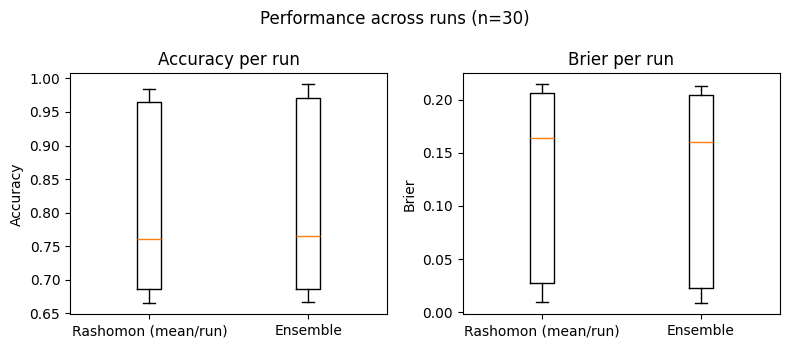

In [3]:
perf_agg = df_runs.agg({
    "acc_mean": ["mean", "std"],
    "brier_mean": ["mean", "std"],
    "acc_ensemble": ["mean", "std"],
    "brier_ensemble": ["mean", "std"],
}).round(4)
print("Performance aggregated across runs (mean ± std over runs):")
print(perf_agg)
print("\nRashomon (mean over models per run): accuracy and Brier averaged across runs.")
print("Ensemble: mean prediction per run, then averaged across runs.")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 3.5))
ax1.boxplot(
    [df_runs["acc_mean"], df_runs["acc_ensemble"]],
    tick_labels=["Rashomon (mean/run)", "Ensemble"],
)
ax1.set_ylabel("Accuracy")
ax1.set_title("Accuracy per run")
ax2.boxplot(
    [df_runs["brier_mean"], df_runs["brier_ensemble"]],
    tick_labels=["Rashomon (mean/run)", "Ensemble"],
)
ax2.set_ylabel("Brier")
ax2.set_title("Brier per run")
plt.suptitle("Performance across runs (n=%d)" % len(df_runs))
plt.tight_layout()
plt.show()

## 2. Predictive multiplicity

Mean variance, ambiguity, disagreement rate (ε=0.05), discrepancy. Optionally: distribution of pointwise variance.

Predictive multiplicity aggregated across runs:


,mean,std,mean ± std
mean_variance,0.0032,0.0024,0.0032 ± 0.0024
ambiguity,0.1491,0.0831,0.1491 ± 0.0831
disagreement_rate,0.2675,0.1785,0.2675 ± 0.1785
discrepancy,0.0845,0.0441,0.0845 ± 0.0441


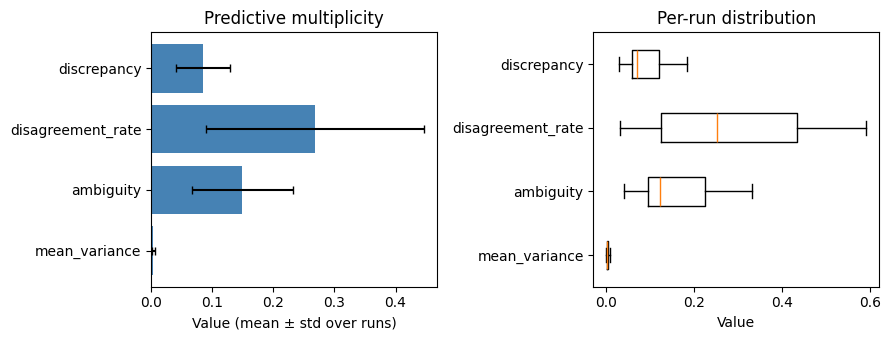

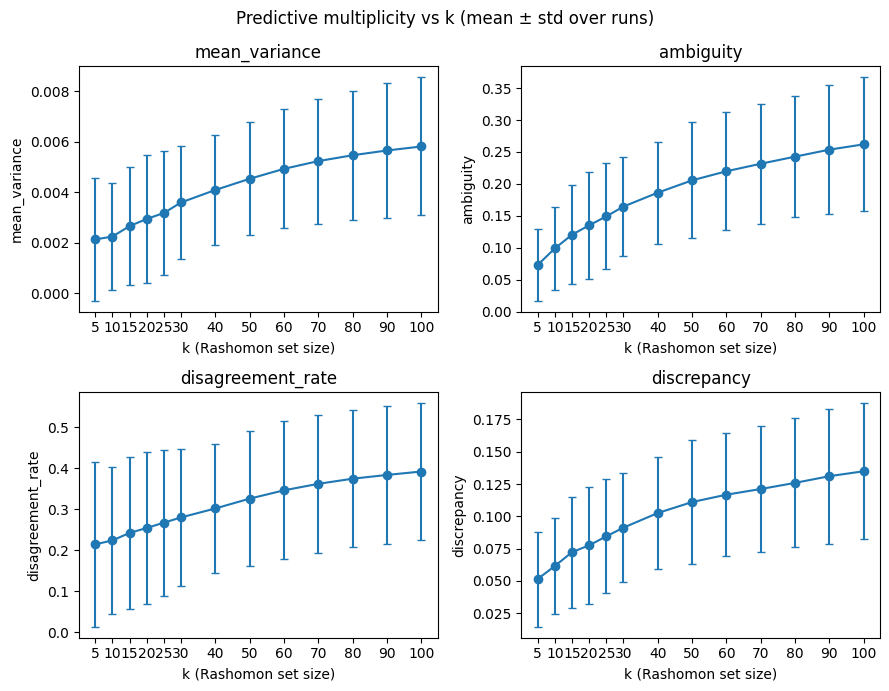

In [4]:
mult_cols = ["mean_variance", "ambiguity", "disagreement_rate", "discrepancy"]
mult_agg = df_runs[mult_cols].agg(["mean", "std"]).T.round(4)
mult_agg.columns = ["mean", "std"]
mult_agg["mean ± std"] = mult_agg.apply(lambda r: f"{r['mean']:.4f} ± {r['std']:.4f}", axis=1)
print("Predictive multiplicity aggregated across runs:")
display(mult_agg[["mean", "std", "mean ± std"]])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 3.5))
x = np.arange(len(mult_cols))
means = df_runs[mult_cols].mean().values
stds = df_runs[mult_cols].std().values
ax1.barh(mult_cols, means, xerr=stds, color="steelblue", capsize=3)
ax1.set_xlabel("Value (mean ± std over runs)")
ax1.set_title("Predictive multiplicity")
ax2.boxplot(
    [df_runs["mean_variance"], df_runs["ambiguity"], df_runs["disagreement_rate"], df_runs["discrepancy"]],
    tick_labels=mult_cols,
    vert=False,
)
ax2.set_xlabel("Value")
ax2.set_title("Per-run distribution")
plt.tight_layout()
plt.show()

# Metrics vs increasing k (Rashomon set size)
if df_k is not None and len(df_k) > 0:
    k_agg = df_k.groupby("k")[mult_cols].agg(["mean", "std"]).reset_index()
    fig2, axes = plt.subplots(2, 2, figsize=(9, 7))
    axes = axes.flatten()
    for i, col in enumerate(mult_cols):
        ax = axes[i]
        k_vals = k_agg["k"].values
        means = k_agg[(col, "mean")].values
        stds = k_agg[(col, "std")].values
        ax.errorbar(k_vals, means, yerr=stds, marker="o", capsize=3)
        ax.set_xlabel("k (Rashomon set size)")
        ax.set_ylabel(col)
        ax.set_title(col)
        ax.set_xticks(k_vals)
    plt.suptitle("Predictive multiplicity vs k (mean ± std over runs)")
    plt.tight_layout()
    plt.show()

## 3. Spatial multiplicity

Pointwise variance (already above), Moran's I (k=30), LISA (k=30), neighborhood agreement, LCAE (k=30): local average of pointwise variance over kNN neighbors.

Spatial multiplicity aggregated across runs:


,mean,std,mean ± std
moran_i,0.1117,0.0857,0.1117 ± 0.0857
n_hh,30.3333,50.8597,30.3333 ± 50.8597
n_ll,201.5667,254.8787,201.5667 ± 254.8787
neighborhood_agreement,0.8232,0.0625,0.8232 ± 0.0625
lcae,0.0026,0.0019,0.0026 ± 0.0019
pointwise_var_mean,0.0032,0.0024,0.0032 ± 0.0024


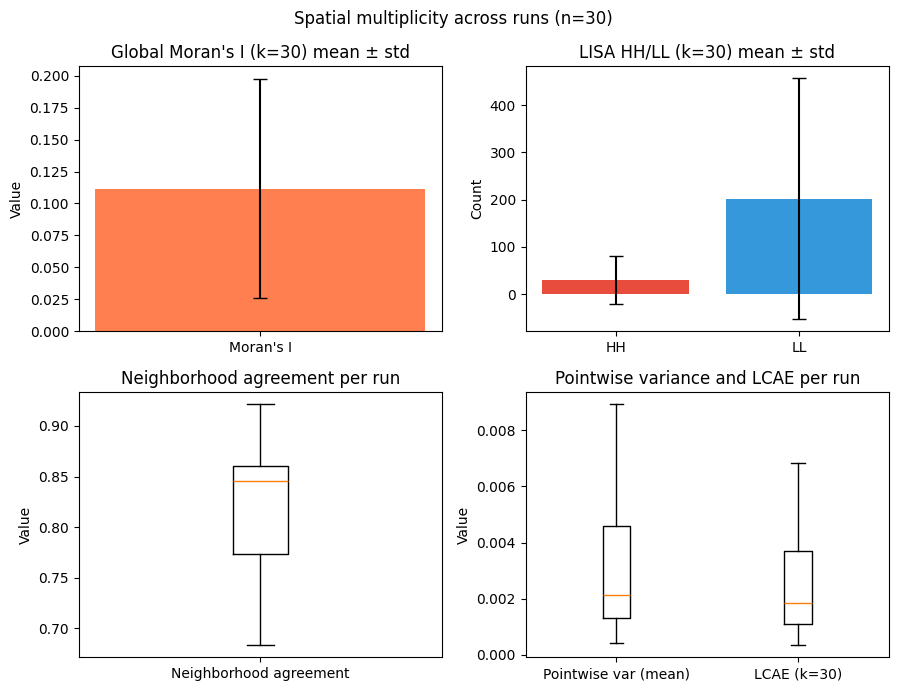

In [5]:
spatial_cols = ["moran_i", "n_hh", "n_ll", "neighborhood_agreement", "lcae", "pointwise_var_mean"]
spatial_agg = df_runs[spatial_cols].agg(["mean", "std"]).T.round(4)
spatial_agg.columns = ["mean", "std"]
spatial_agg["mean ± std"] = spatial_agg.apply(lambda r: f"{r['mean']:.4f} ± {r['std']:.4f}", axis=1)
print("Spatial multiplicity aggregated across runs:")
display(spatial_agg[["mean", "std", "mean ± std"]])

fig, axes = plt.subplots(2, 2, figsize=(9, 7))
ax = axes[0, 0]
ax.bar(["Moran's I"], [df_runs["moran_i"].mean()], yerr=[df_runs["moran_i"].std()], color="coral", capsize=5)
ax.set_ylabel("Value")
ax.set_title("Global Moran's I (k=30) mean ± std")
ax = axes[0, 1]
ax.bar(["HH", "LL"], [df_runs["n_hh"].mean(), df_runs["n_ll"].mean()], yerr=[df_runs["n_hh"].std(), df_runs["n_ll"].std()], color=["#e74c3c", "#3498db"], capsize=5)
ax.set_ylabel("Count")
ax.set_title("LISA HH/LL (k=30) mean ± std")
ax = axes[1, 0]
ax.boxplot(df_runs["neighborhood_agreement"], tick_labels=["Neighborhood agreement"])
ax.set_ylabel("Value")
ax.set_title("Neighborhood agreement per run")
ax = axes[1, 1]
ax.boxplot([df_runs["pointwise_var_mean"], df_runs["lcae"]], tick_labels=["Pointwise var (mean)", "LCAE (k=30)"])
ax.set_ylabel("Value")
ax.set_title("Pointwise variance and LCAE per run")
plt.suptitle("Spatial multiplicity across runs (n=%d)" % len(df_runs))
plt.tight_layout()
plt.show()

## Summary table (all metrics)

Single table combining performance, predictive multiplicity, and spatial metrics for reporting.

In [6]:
def _mean_std(s):
    m, s_ = s.mean(), s.std()
    return f"{m:.4f} ± {s_:.4f}" if len(s) > 1 else f"{m:.4f}"

report_rows = [
    ("Performance", "Accuracy (mean over Rashomon)", _mean_std(df_runs["acc_mean"])),
    ("Performance", "Brier (mean over Rashomon)", _mean_std(df_runs["brier_mean"])),
    ("Performance", "Accuracy (ensemble)", _mean_std(df_runs["acc_ensemble"])),
    ("Performance", "Brier (ensemble)", _mean_std(df_runs["brier_ensemble"])),
    ("Predictive multiplicity", "Mean variance", _mean_std(df_runs["mean_variance"])),
    ("Predictive multiplicity", "Ambiguity", _mean_std(df_runs["ambiguity"])),
    ("Predictive multiplicity", f"Disagreement rate (ε={EPSILON})", _mean_std(df_runs["disagreement_rate"])),
    ("Predictive multiplicity", "Discrepancy", _mean_std(df_runs["discrepancy"])),
    ("Spatial multiplicity", "Pointwise variance (mean)", _mean_std(df_runs["pointwise_var_mean"])),
    ("Spatial multiplicity", "Moran's I (k=30)", _mean_std(df_runs["moran_i"])),
    ("Spatial multiplicity", "LISA HH count (k=30)", _mean_std(df_runs["n_hh"])),
    ("Spatial multiplicity", "LISA LL count (k=30)", _mean_std(df_runs["n_ll"])),
    ("Spatial multiplicity", "Neighborhood agreement", _mean_std(df_runs["neighborhood_agreement"])),
    ("Spatial multiplicity", "LCAE (k=30)", _mean_std(df_runs["lcae"])),
]
report = pd.DataFrame(report_rows, columns=["Category", "Metric", "Value (mean ± std over runs)"])
datasets = ", ".join(df_runs["dataset"].unique())
print(f"Datasets: {datasets}, n_runs={len(df_runs)}, K={K}, k_nn={K_NN}")
display(report)

Datasets: breast_cancer, compas, german, n_runs=30, K=25, k_nn=30


,Category,Metric,Value (mean ± std over runs)
0,Performance,Accuracy (mean over Rashomon),0.8006 ± 0.1285
1,Performance,Brier (mean over Rashomon),0.1337 ± 0.0827
2,Performance,Accuracy (ensemble),0.8054 ± 0.1289
3,Performance,Brier (ensemble),0.1306 ± 0.0830
4,Predictive multiplicity,Mean variance,0.0032 ± 0.0024
5,Predictive multiplicity,Ambiguity,0.1491 ± 0.0831
6,Predictive multiplicity,Disagreement rate (ε=0.05),0.2675 ± 0.1785
7,Predictive multiplicity,Discrepancy,0.0845 ± 0.0441
8,Spatial multiplicity,Pointwise variance (mean),0.0032 ± 0.0024
9,Spatial multiplicity,Moran's I (k=30),0.1117 ± 0.0857
